<a href="https://colab.research.google.com/github/tanderson5/Cervical-Cancer-Detection/blob/main/pap_smear_classification_EfficientNet_B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pap Smear Cytology Classification — EfficientNet-B4

**Classes:** NILM (normal) · LSIL (mild abnormality) · HSIL (severe / precancerous)

**Dataset:** Brown Multicellular ThinPrep Database — 200 images per class (600 total)

---

### Instructions
1. **Runtime → Change runtime type → T4 GPU**
2. Upload your image folder to Google Drive as-is (flat folder of 600 images)
3. Update `RAW_DATA_PATH` in Cell 2 to point to your Drive folder
4. Run all cells in order (Runtime → Run all)

### Notebook structure
| Cell | What it does |
|------|--------------|
| 1 | Install dependencies |
| 2 | Mount Google Drive + config |
| 3 | Data setup — parse filenames → train/val/test split |
| 4 | EDA — class counts, image stats, sample grid |
| 5 | EfficientNet-B4 — model, training loop, evaluation |
| 6 | Results — metrics, confusion matrices, training curves |
| 7 | Report — comparison table vs paper baselines |

## Cell 1 — Install dependencies

In [ ]:
!pip install -q torch torchvision torchmetrics scikit-learn matplotlib seaborn tqdm pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.6 MB/s eta 0:00:00


## Cell 2 — Mount Google Drive + global config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── ✏️  UPDATE THIS PATH to where your image folder lives in Drive ────────────
RAW_DATA_PATH = Path('/content/drive/MyDrive/BMT')
# ─────────────────────────────────────────────────────────────────────────────

DATA_ROOT  = Path('/content/data')          # structured split will go here
RESULTS    = Path('/content/results/efficientnet_b4')
EDA_OUT    = Path('/content/eda_outputs')
REPORT_OUT = Path('/content/report')

for p in [DATA_ROOT, RESULTS, EDA_OUT, REPORT_OUT]:
    p.mkdir(parents=True, exist_ok=True)

CLASSES     = ['NILM', 'LSIL', 'HSIL']
NUM_CLASSES = len(CLASSES)
SEED        = 42

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'Raw data path exists: {RAW_DATA_PATH.exists()}')

Mounted at /content/drive
Device : cuda
Raw data path exists: True


## Cell 3 — Data setup
Parses filenames like `HSIL (1).jpg`, `NIL (43).jpg` and creates a stratified 70/15/15 train/val/test split.

In [ ]:
import random
import shutil
from collections import defaultdict

LABEL_MAP = {'HSIL': 'HSIL', 'LSIL': 'LSIL', 'NIL': 'NILM'}
IMG_EXTS  = {'.jpg', '.jpeg', '.png'}
VAL_RATIO  = 0.15
TEST_RATIO = 0.15


def parse_label(filename: str):
    name = Path(filename).stem
    for raw in LABEL_MAP:
        if name.upper().startswith(raw):
            return LABEL_MAP[raw]
    return None


def build_split(src: Path, dst: Path, seed: int = 42):
    if not src.exists():
        raise FileNotFoundError(f'Source folder not found: {src}')

    # Wipe destination so re-running is safe
    if dst.exists():
        shutil.rmtree(dst)

    by_class = defaultdict(list)
    unrecognized = []
    for f in sorted(src.iterdir()):
        if f.suffix.lower() not in IMG_EXTS:
            continue
        label = parse_label(f.name)
        if label is None:
            unrecognized.append(f.name)
        else:
            by_class[label].append(f)

    if unrecognized:
        print(f'{len(unrecognized)} unrecognized files skipped (first 5):')
        for n in unrecognized[:5]: print(f'   {n}')

    print('\n── Found images ──────────────────────────────')
    for cls, files in sorted(by_class.items()):
        print(f'  {cls:<6}: {len(files)}')
    print(f'  Total : {sum(len(v) for v in by_class.values())}')

    rng = random.Random(seed)
    splits = {'train': {}, 'val': {}, 'test': {}}

    print('\n── Split sizes ───────────────────────────────')
    for cls, files in sorted(by_class.items()):
        rng.shuffle(files)
        n       = len(files)
        n_val   = max(1, round(n * VAL_RATIO))
        n_test  = max(1, round(n * TEST_RATIO))
        n_train = n - n_val - n_test
        splits['test'][cls]  = files[:n_test]
        splits['val'][cls]   = files[n_test:n_test + n_val]
        splits['train'][cls] = files[n_test + n_val:]
        print(f'  {cls:<6}: train={n_train}  val={n_val}  test={n_test}')

    print('\n── Copying files ─────────────────────────────')
    total = 0
    for split_name, class_dict in splits.items():
        for cls, files in class_dict.items():
            out = dst / split_name / cls
            out.mkdir(parents=True, exist_ok=True)
            for i, src_f in enumerate(files):
                ext = src_f.suffix.lower()
                shutil.copy2(src_f, out / f'{cls}_{split_name}_{i+1:03d}{ext}')
                total += 1
    print(f'  Done — {total} images copied to {dst}/')

    print('\n── Verification ──────────────────────────────')
    print(f'  {"Class":<8}  {"train":<8}  {"val":<8}  {"test":<8}')
    print('  ' + '-' * 38)
    for cls in sorted(by_class.keys()):
        row = [len(list((dst / s / cls).iterdir())) for s in ['train','val','test']]
        print(f'  {cls:<8}  {row[0]:<8}  {row[1]:<8}  {row[2]:<8}')
    print(f'\n Dataset ready at {dst}/')


build_split(RAW_DATA_PATH, DATA_ROOT, seed=SEED)


── Found images ──────────────────────────────
  HSIL  : 200
  LSIL  : 200
  NILM  : 200
  Total : 600

── Split sizes ───────────────────────────────
  HSIL  : train=140  val=30  test=30
  LSIL  : train=140  val=30  test=30
  NILM  : train=140  val=30  test=30

── Copying files ─────────────────────────────
  Done — 600 images copied to /content/data/

── Verification ──────────────────────────────
  Class     train     val       test    
  --------------------------------------
  HSIL      140       30        30      
  LSIL      140       30        30      
  NILM      140       30        30      

 Dataset ready at /content/data/


## Cell 4 — Exploratory Data Analysis

  EDA — Pap Smear Classification Dataset

TRAIN (420 images)
  NILM  :  140  (33.3%)
  LSIL  :  140  (33.3%)
  HSIL  :  140  (33.3%)

VAL (90 images)
  NILM  :   30  (33.3%)
  LSIL  :   30  (33.3%)
  HSIL  :   30  (33.3%)

TEST (90 images)
  NILM  :   30  (33.3%)
  LSIL  :   30  (33.3%)
  HSIL  :   30  (33.3%)

Imbalance ratio (train): 1.00x
  → Reasonably balanced ✓

── Image size analysis (train sample) ────────
  Width  : min=1920  max=3264  mean=2682
  Height : min=1080  max=1840  mean=1511


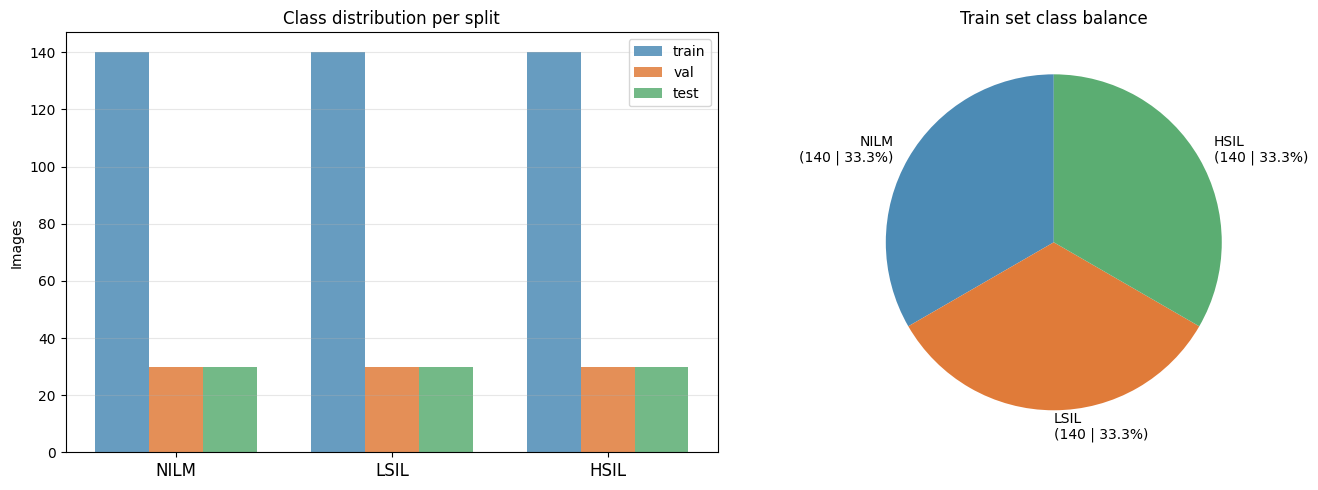

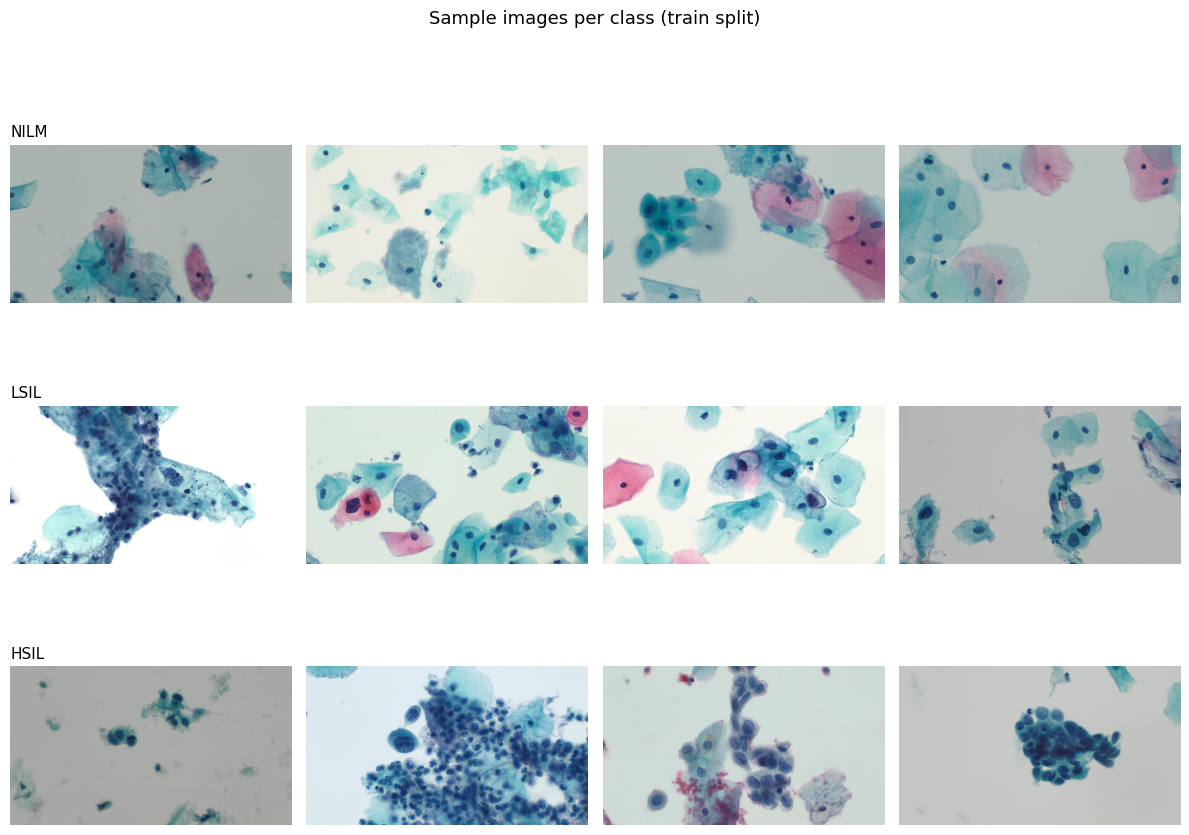


EDA plots saved to /content/eda_outputs/


In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display


def count_samples(root: Path):
    counts = {}
    for split in ['train', 'val', 'test']:
        counts[split] = {}
        for cls in CLASSES:
            p = root / split / cls
            imgs = list(p.glob('*.[jp][pn]g')) + list(p.glob('*.jpeg')) if p.exists() else []
            counts[split][cls] = len(imgs)
    return counts


counts = count_samples(DATA_ROOT)

print('=' * 50)
print('EDA — Pap Smear Classification Dataset')
print('=' * 50)
for split, cls_counts in counts.items():
    total = sum(cls_counts.values())
    print(f'\n{split.upper()} ({total} images)')
    for cls in CLASSES:
        n = cls_counts[cls]
        print(f'  {cls:<6}: {n:>4}  ({100*n/total:.1f}%)')

# Imbalance
train_vals = [counts['train'][c] for c in CLASSES]
ratio = max(train_vals) / max(min(train_vals), 1)
print(f'\nImbalance ratio (train): {ratio:.2f}x')
print('  → Reasonably balanced ✓' if ratio <= 1.5 else '  → Moderate imbalance — class weights applied in loss')

# Image size stats
print('\n── Image size analysis (train sample) ────────')
widths, heights = [], []
for cls in CLASSES:
    imgs = list((DATA_ROOT / 'train' / cls).glob('*.[jp][pn]g'))[:20]
    for p in imgs:
        try:
            with Image.open(p) as im:
                widths.append(im.width); heights.append(im.height)
        except: pass
if widths:
    print(f'  Width  : min={min(widths)}  max={max(widths)}  mean={np.mean(widths):.0f}')
    print(f'  Height : min={min(heights)}  max={max(heights)}  mean={np.mean(heights):.0f}')
    if len(set(zip(widths, heights))) == 1:
        print(f'  All images are {widths[0]}×{heights[0]} ✓')

# Plot 1: class distribution
bar_colors = ['#4C8BB5', '#E07B39', '#5BAD72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(CLASSES))
w = 0.25
for i, (split, color) in enumerate(zip(['train','val','test'], bar_colors)):
    vals = [counts[split][c] for c in CLASSES]
    axes[0].bar(x + i*w, vals, w, label=split, color=color, alpha=0.85)
axes[0].set_xticks(x + w); axes[0].set_xticklabels(CLASSES, fontsize=12)
axes[0].set_ylabel('Images'); axes[0].set_title('Class distribution per split')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

train_vals = [counts['train'][c] for c in CLASSES]
total = sum(train_vals)
axes[1].pie(train_vals,
    labels=[f'{c}\n({v} | {v/total*100:.1f}%)' for c,v in zip(CLASSES, train_vals)],
    colors=bar_colors, startangle=90)
axes[1].set_title('Train set class balance')
plt.tight_layout()
plt.savefig(EDA_OUT / 'class_distribution.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()

# Plot 2: sample image grid
n_per_class = 4
fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(3*n_per_class, 3*len(CLASSES)))
fig.suptitle('Sample images per class (train split)', fontsize=13, y=1.01)
for row, cls in enumerate(CLASSES):
    imgs = list((DATA_ROOT / 'train' / cls).glob('*.[jp][pn]g'))[:n_per_class]
    for col in range(n_per_class):
        ax = axes[row][col]; ax.axis('off')
        if col < len(imgs):
            try: ax.imshow(Image.open(imgs[col]).convert('RGB'))
            except: pass
        if col == 0: ax.set_title(cls, fontsize=11, loc='left')
plt.tight_layout()
plt.savefig(EDA_OUT / 'sample_grid.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()
print(f'\nEDA plots saved to {EDA_OUT}/')

## Cell 5 — EfficientNet-B4 training

**Key design choices vs VGG19/ResNet50 baselines:**
- EfficientNet-B4 uses compound scaling — more accurate per parameter than VGG19/ResNet50
- 2-stage fine-tuning: classifier head only (epochs 1–8) → full model (epochs 9–50)
- Weighted sampler + weighted loss for class imbalance
- Mixup augmentation + label smoothing to reduce overfitting on the small dataset
- Cosine LR annealing + gradient clipping for stable training
- Test-time augmentation (TTA) at inference for a free accuracy boost

In [ ]:
import json
import time
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, models, transforms
from torchmetrics import Accuracy, F1Score, AUROC
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm.notebook import tqdm

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE       = 380
BATCH_SIZE     = 16
NUM_EPOCHS     = 50
LR_HEAD        = 3e-4
LR_FINETUNE    = 5e-5
UNFREEZE_EPOCH = 8
LABEL_SMOOTH   = 0.1
MIXUP_ALPHA    = 0.2
GRAD_CLIP      = 1.0
TTA_RUNS       = 5

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms ────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 40, IMG_SIZE + 40)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
tta_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Mixup ─────────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ── Data loaders ──────────────────────────────────────────────────────────────
train_ds = datasets.ImageFolder(DATA_ROOT / 'train', transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_ROOT / 'val',   transform=val_tf)
test_ds  = datasets.ImageFolder(DATA_ROOT / 'test',  transform=val_tf)

labels       = [s[1] for s in train_ds.samples]
class_counts = np.bincount(labels)
sample_wts   = 1.0 / class_counts[labels]
sampler      = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

loss_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(DEVICE)
loss_weights = loss_weights / loss_weights.sum() * NUM_CLASSES

print(f'Class mapping : {train_ds.class_to_idx}')
print(f'Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}')

# ── Model ─────────────────────────────────────────────────────────────────────
weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1
model   = models.efficientnet_b4(weights=weights)
in_feat = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_feat, NUM_CLASSES),
)
for name, p in model.named_parameters():
    if 'classifier' not in name:
        p.requires_grad = False
model = model.to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
active = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {total:,} total  |  {active:,} trainable (head only)')

# ── Training helpers ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=loss_weights, label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
scaler    = torch.amp.GradScaler(enabled=DEVICE.type == 'cuda')


def train_one_epoch(model, loader):
    model.train()
    loss_sum = correct = total = 0
    for imgs, lbls in tqdm(loader, desc='  train', leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        imgs, y_a, y_b, lam = mixup_data(imgs, lbls, MIXUP_ALPHA)
        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                            enabled=DEVICE.type == 'cuda'):
            logits = model(imgs)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * lbls.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += lbls.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_sum = correct = total = 0
    all_probs, all_preds, all_lbls = [], [], []
    for imgs, lbls in tqdm(loader, desc='  eval', leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, lbls)
        probs  = torch.softmax(logits, 1)
        preds  = logits.argmax(1)
        loss_sum += loss.item() * lbls.size(0)
        correct  += (preds == lbls).sum().item()
        total    += lbls.size(0)
        all_probs.append(probs.cpu()); all_preds.append(preds.cpu()); all_lbls.append(lbls.cpu())
    return (loss_sum/total, correct/total,
            torch.cat(all_probs), torch.cat(all_preds), torch.cat(all_lbls))


# ── Training loop ─────────────────────────────────────────────────────────────
best_val_f1 = 0.0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
unfrozen = False

print(f'\n{"="*60}')
print(f'  Training EfficientNet-B4  ({NUM_EPOCHS} epochs)')
print(f'{"="*60}')

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == UNFREEZE_EPOCH and not unfrozen:
        for p in model.parameters(): p.requires_grad = True
        for g in optimizer.param_groups: g['lr'] = LR_FINETUNE
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - UNFREEZE_EPOCH + 1)
        unfrozen = True
        print(f'Backbone unfrozen at epoch {epoch}, LR → {LR_FINETUNE}')

    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    vl_loss, vl_acc, vl_probs, vl_preds, vl_lbls = evaluate(model, val_loader)
    scheduler.step()

    vl_f1 = F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro')(
        vl_preds, vl_lbls).item()

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

    star = ''
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), RESULTS / 'best_model.pth')
        star = '  ★ best'

    print(f'Ep {epoch:02d}/{NUM_EPOCHS}  '
          f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3f}  '
          f'vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.3f}  '
          f'vl_f1={vl_f1:.4f}  ({time.time()-t0:.0f}s){star}')

print(f'\nBest val F1: {best_val_f1:.4f}  — checkpoint saved to {RESULTS}/best_model.pth')

Class mapping : {'HSIL': 0, 'LSIL': 1, 'NILM': 2}
Train: 420  |  Val: 90  |  Test: 90
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 184MB/s]


Parameters: 17,553,995 total  |  5,379 trainable (head only)

  Training EfficientNet-B4  (50 epochs)


  train:   0%|          | 0/27 [00:00<?, ?it/s]

  eval:   0%|          | 0/6 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/6 [00:00<?, ?it/s]

Ep 49/50  tr_loss=nan  tr_acc=0.340  vl_loss=nan  vl_acc=0.333  vl_f1=0.1667  (31s)


  train:   0%|          | 0/27 [00:00<?, ?it/s]

  eval:   0%|          | 0/6 [00:00<?, ?it/s]

Ep 50/50  tr_loss=nan  tr_acc=0.314  vl_loss=nan  vl_acc=0.333  vl_f1=0.1667  (31s)

Best val F1: 0.7141  — checkpoint saved to /content/results/efficientnet_b4/best_model.pth


## Cell 6 — Evaluation (standard + TTA)

  eval:   0%|          | 0/6 [00:00<?, ?it/s]


----------------------------------------------------  [TEST (STANDARD)]
  Accuracy   : 0.6778  (67.78%)
  Macro F1   : 0.6619
  AUC-ROC    : 0.8415
  F1 NILM   : 0.7302
  F1 LSIL   : 0.5333
  F1 HSIL   : 0.7222

              precision    recall  f1-score   support

        NILM     0.6970    0.7667    0.7302        30
        LSIL     0.8000    0.4000    0.5333        30
        HSIL     0.6190    0.8667    0.7222        30

    accuracy                         0.6778        90
   macro avg     0.7053    0.6778    0.6619        90
weighted avg     0.7053    0.6778    0.6619        90



  TTA 1/5:   0%|          | 0/6 [00:00<?, ?it/s]

  TTA 2/5:   0%|          | 0/6 [00:00<?, ?it/s]

  TTA 3/5:   0%|          | 0/6 [00:00<?, ?it/s]

  TTA 4/5:   0%|          | 0/6 [00:00<?, ?it/s]

  TTA 5/5:   0%|          | 0/6 [00:00<?, ?it/s]


----------------------------------------------------  [TEST (TTA)]
  Accuracy   : 0.6889  (68.89%)
  Macro F1   : 0.6727
  AUC-ROC    : 0.8589
  F1 NILM   : 0.7742
  F1 LSIL   : 0.5217
  F1 HSIL   : 0.7222

              precision    recall  f1-score   support

        NILM     0.7500    0.8000    0.7742        30
        LSIL     0.7500    0.4000    0.5217        30
        HSIL     0.6190    0.8667    0.7222        30

    accuracy                         0.6889        90
   macro avg     0.7063    0.6889    0.6727        90
weighted avg     0.7063    0.6889    0.6727        90



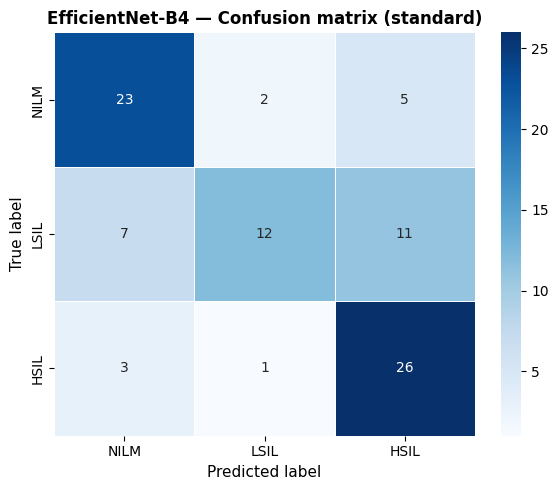

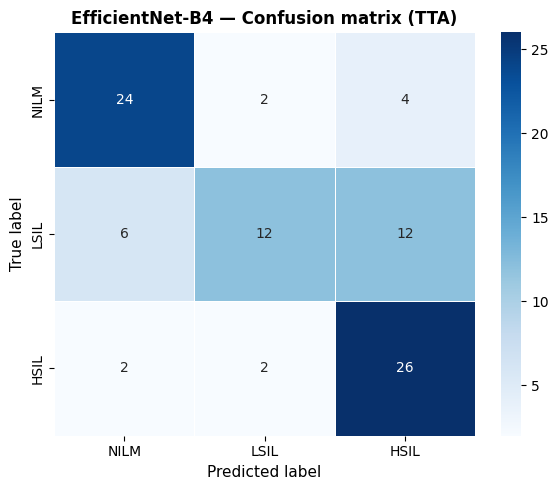

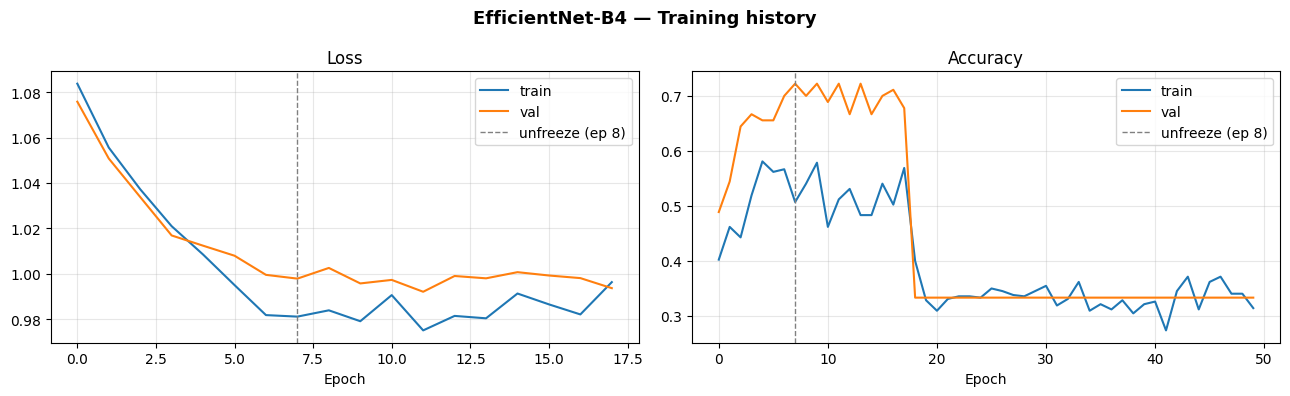

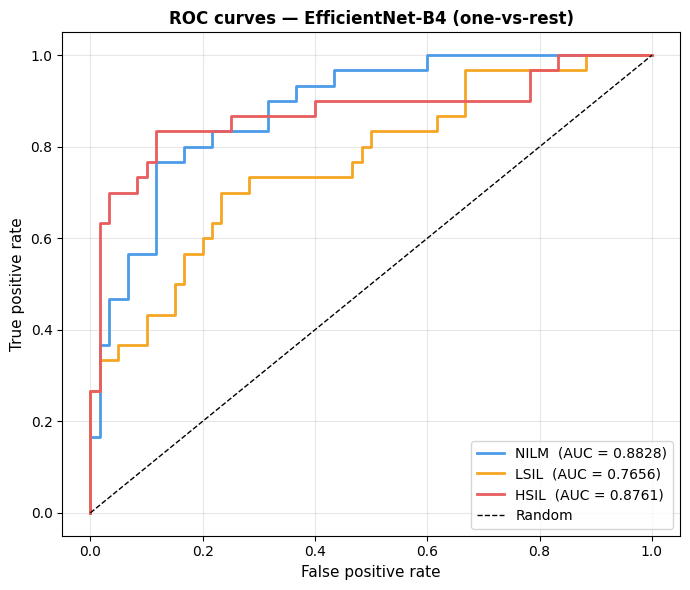


  FINAL RESULTS
  Standard  |  Acc: 0.6778  F1: 0.6619  AUC: 0.8415
  With TTA   |  Acc: 0.6889  F1: 0.6727  AUC: 0.8589

  All outputs saved to /content/results/efficientnet_b4/


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display

# Load best checkpoint
model.load_state_dict(torch.load(RESULTS / 'best_model.pth', map_location=DEVICE))


def compute_metrics(probs, preds, labels, tag='test'):
    acc      = Accuracy(task='multiclass', num_classes=NUM_CLASSES)(preds, labels).item()
    f1_macro = F1Score(task='multiclass',  num_classes=NUM_CLASSES, average='macro')(preds, labels).item()
    f1_per   = F1Score(task='multiclass',  num_classes=NUM_CLASSES, average='none')(preds, labels).tolist()
    auc      = AUROC(task='multiclass',    num_classes=NUM_CLASSES)(probs, labels).item()
    cm       = confusion_matrix(labels.numpy(), preds.numpy())
    report   = classification_report(labels.numpy(), preds.numpy(),
                                     target_names=CLASSES, digits=4)
    print(f'\n{"-"*52}  [{tag.upper()}]')
    print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Macro F1   : {f1_macro:.4f}')
    print(f'  AUC-ROC    : {auc:.4f}')
    for cls, s in zip(CLASSES, f1_per):
        print(f'  F1 {cls:<6} : {s:.4f}')
    print(f'\n{report}')
    return {
        'accuracy': round(acc, 4), 'macro_f1': round(f1_macro, 4), 'auc': round(auc, 4),
        'f1_per_class': {c: round(s, 4) for c, s in zip(CLASSES, f1_per)},
        'confusion_matrix': cm.tolist(),
    }


@torch.no_grad()
def evaluate_tta(model, dataset, n_runs=TTA_RUNS):
    model.eval()
    orig_tf = dataset.transform
    dataset.transform = tta_tf
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
    probs_sum = None
    all_lbls  = []
    for run in range(n_runs):
        run_probs, run_lbls = [], []
        for imgs, lbls in tqdm(loader, desc=f'  TTA {run+1}/{n_runs}', leave=False):
            run_probs.append(torch.softmax(model(imgs.to(DEVICE)), 1).cpu())
            if run == 0: run_lbls.append(lbls)
        bp = torch.cat(run_probs)
        probs_sum = bp if probs_sum is None else probs_sum + bp
        if run == 0: all_lbls = torch.cat(run_lbls)
    dataset.transform = orig_tf
    avg = probs_sum / n_runs
    return avg, avg.argmax(1), all_lbls


def plot_cm(cm_arr, title, path):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_ylabel('True label',      fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    display(plt.gcf()); plt.close()


# Standard eval
_, _, ts_probs, ts_preds, ts_lbls = evaluate(model, test_loader)
metrics_std = compute_metrics(ts_probs, ts_preds, ts_lbls, tag='test (standard)')

# TTA eval
tta_probs, tta_preds, tta_lbls = evaluate_tta(model, test_ds)
metrics_tta = compute_metrics(tta_probs, tta_preds, tta_lbls, tag='test (TTA)')

# Save raw probs for ROC curves
np.save(RESULTS / 'test_probs.npy',  ts_probs.numpy())
np.save(RESULTS / 'test_labels.npy', ts_lbls.numpy())

# Plot confusion matrices
plot_cm(np.array(metrics_std['confusion_matrix']),
        'EfficientNet-B4 — Confusion matrix (standard)',
        RESULTS / 'confusion_matrix.png')
plot_cm(np.array(metrics_tta['confusion_matrix']),
        'EfficientNet-B4 — Confusion matrix (TTA)',
        RESULTS / 'confusion_matrix_tta.png')

# Training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, key, title in zip(axes, ['loss','acc'], ['Loss','Accuracy']):
    ax.plot(history[f'train_{key}'], label='train', linewidth=1.5)
    ax.plot(history[f'val_{key}'],   label='val',   linewidth=1.5)
    ax.axvline(UNFREEZE_EPOCH - 1, color='gray', linestyle='--',
               linewidth=1, label=f'unfreeze (ep {UNFREEZE_EPOCH})')
    ax.set_title(title, fontsize=12); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('EfficientNet-B4 — Training history', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'training_history.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()

# ROC curves
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.preprocessing import label_binarize
labels_bin = label_binarize(ts_lbls.numpy(), classes=range(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(7, 6))
roc_colors = ['#4C9BE8', '#F5A623', '#E85D5D']
for i, (cls, color) in enumerate(zip(CLASSES, roc_colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], ts_probs.numpy()[:, i])
    roc_auc = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls}  (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
ax.set_xlabel('False positive rate', fontsize=11)
ax.set_ylabel('True positive rate',  fontsize=11)
ax.set_title('ROC curves — EfficientNet-B4 (one-vs-rest)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'roc_curves.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()

# Save metrics JSON
def strip_cm(d): return {k:v for k,v in d.items() if k != 'confusion_matrix'}
with open(RESULTS / 'metrics.json', 'w') as f:
    json.dump({'standard': strip_cm(metrics_std), 'tta': strip_cm(metrics_tta)}, f, indent=2)

print(f'\n{"="*60}')
print('  FINAL RESULTS')
print(f'{"="*60}')
for tag, m in [('Standard', metrics_std), ('With TTA ', metrics_tta)]:
    print(f'  {tag}  |  Acc: {m["accuracy"]:.4f}  F1: {m["macro_f1"]:.4f}  AUC: {m["auc"]:.4f}')
print(f'\n  All outputs saved to {RESULTS}/')